In [2]:
!pip install playwright nest_asyncio ultralytics
!playwright install chromium
!playwright install-deps

import asyncio
import os
import random
import time
import json
from playwright.async_api import async_playwright
import nest_asyncio

nest_asyncio.apply()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.6 MB/s eta 0:00:00
(node:1927) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
167.3 MiB [] 0% 0.0s167.3 MiB [] 0% 22.3s167.3 MiB [] 0% 15.5s167.3 MiB [] 0% 9.7s167.3 MiB [] 1% 4.5s167.3 MiB [] 2% 3.2s167.3 MiB [] 3% 2.7s167.3 MiB [] 4% 2.7s167.3 MiB [] 5% 2.5s167.3 MiB [] 6% 2.2s167.3 MiB [] 7% 2.0s167.3 MiB [] 8% 1.9s167.3 MiB [] 9% 1.8s167.3 MiB [] 11% 1.7s167.3 MiB [] 12% 1.6s167.3 MiB [] 13% 1.6s167.3 MiB [] 14% 1.5s167.3 MiB [] 15% 1.5s167.3 MiB [] 16% 1.5s167.3 MiB [] 17% 1.4s167.3 MiB [] 19% 1.4s167.3 MiB [] 21% 1.3s167.3 MiB [] 22% 1.3s167.3 MiB [] 24% 1.2s167.3 MiB [] 26% 1.1s167.3 MiB [] 27% 1.1s167.3 MiB

In [3]:
# Configuration des dossiers
BASE_DIR = "yolo_dataset"
os.makedirs(f"{BASE_DIR}/images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels", exist_ok=True)

# Mapping des classes (Index YOLO)
CLASSES = {
    "button": 0,
    "input": 1,
    "a": 2,          # Link
    "select": 3,     # Dropdown
    "input[type='checkbox']": 4
}

In [4]:
import asyncio
from playwright.async_api import async_playwright
import os, random, time, nest_asyncio

nest_asyncio.apply()

BASE_DIR = "yolo_dataset_pro"
os.makedirs(f"{BASE_DIR}/images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels", exist_ok=True)

CLASSES = {"button": 0, "input": 1, "a": 2, "select": 3, "input[type='checkbox']": 4}

# List kbir mte3 sites makhdumin b framework UI kima React/Angular/Vue
SITES = [
    "https://v4.mui.com/getting-started/templates/dashboard/",
    "https://ant.design/components/overview/",
    "https://getbootstrap.com/docs/5.0/components/buttons/",
    "https://flowbite.com/docs/components/forms/",
    "https://daisyui.com/components/button/",
    "https://semantic-ui.com/elements/button.html",
    "https://github.com/login",
    "https://www.ebay.com",
    "https://www.booking.com",
    "https://www.wikipedia.org",
    "https://www.reddit.com/login",
    "https://www.canva.com",
    "https://vuedesigntokens.com/",
    "https://primereact.org/installation/"
]

async def auto_label_ui(page, count):
    # Get image size
    metrics = await page.evaluate("() => ({w: window.innerWidth, h: window.innerHeight})")
    img_w, img_h = metrics['w'], metrics['h']

    img_path = f"{BASE_DIR}/images/ui_{count}.png"
    label_path = f"{BASE_DIR}/labels/ui_{count}.txt"

    await page.screenshot(path=img_path)

    yolo_lines = []
    for selector, class_id in CLASSES.items():
        elements = await page.query_selector_all(selector)
        for el in elements:
            try:
                box = await el.bounding_box()
                if box and box['width'] > 5 and box['height'] > 5:
                    x_center = (box['x'] + box['width'] / 2) / img_w
                    y_center = (box['y'] + box['height'] / 2) / img_h
                    w = box['width'] / img_w
                    h = box['height'] / img_h
                    if 0 <= x_center <= 1 and 0 <= y_center <= 1:
                        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
            except: continue

    if yolo_lines:
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))
        return True
    os.remove(img_path)
    return False

async def run_massive_collection():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        img_count = 0
        target = 500

        for site in SITES:
            if img_count >= target: break
            print(f"🚀 Trying: {site}")
            context = await browser.new_context(viewport={'width': 1280, 'height': 800})
            page = await context.new_page()

            try:
                # Timeout a9al (40s) bech ma nob9awch nestannaw barcha
                await page.goto(site, wait_until="domcontentloaded", timeout=40000)
                await asyncio.sleep(2)

                # Take 30 shots per site with random scrolling
                for _ in range(35):
                    if img_count >= target: break
                    if await auto_label_ui(page, img_count):
                        img_count += 1
                        if img_count % 50 == 0: print(f"📍 Milestone: {img_count}/500")

                    await page.evaluate(f"window.scrollBy(0, {random.randint(400, 900)})")
                    await asyncio.sleep(0.5)
            except Exception as e:
                print(f"⚠️ Skipped {site} due to error.")

            await context.close()
        await browser.close()
        print(f"🏁 DONE! Total images: {img_count}")

asyncio.run(run_massive_collection())

🚀 Trying: https://v4.mui.com/getting-started/templates/dashboard/
🚀 Trying: https://ant.design/components/overview/
📍 Milestone: 50/500
🚀 Trying: https://getbootstrap.com/docs/5.0/components/buttons/
📍 Milestone: 100/500
🚀 Trying: https://flowbite.com/docs/components/forms/
🚀 Trying: https://daisyui.com/components/button/
📍 Milestone: 150/500
🚀 Trying: https://semantic-ui.com/elements/button.html
📍 Milestone: 200/500
🚀 Trying: https://github.com/login
🚀 Trying: https://www.ebay.com
📍 Milestone: 250/500
🚀 Trying: https://www.booking.com
📍 Milestone: 300/500
🚀 Trying: https://www.wikipedia.org
📍 Milestone: 350/500
🚀 Trying: https://www.reddit.com/login
🚀 Trying: https://www.canva.com
📍 Milestone: 400/500
⚠️ Skipped https://www.canva.com due to error.
🚀 Trying: https://vuedesigntokens.com/
⚠️ Skipped https://vuedesigntokens.com/ due to error.
🚀 Trying: https://primereact.org/installation/
📍 Milestone: 450/500
🏁 DONE! Total images: 452


In [5]:
import os
import random
import shutil

# Create train/val split
images = [f for f in os.listdir(f"{BASE_DIR}/images") if f.endswith('.png')]
random.shuffle(images)

split = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

# Simple YAML creation
import yaml
config = {
    'path': f'/content/{BASE_DIR}',
    'train': 'images', # We'll keep it simple for now
    'val': 'images',
    'nc': 5,
    'names': ['button', 'input_field', 'link', 'dropdown', 'checkbox']
}

with open('data.yaml', 'w') as f:
    yaml.dump(config, f)

In [7]:
from ultralytics import YOLO

# Load YOLOv8 Nano (best for speed/mobile/web)
model = YOLO('yolov8n.pt')

# Training
results = model.train(
    data='data.yaml',
    epochs=100,         # 100 epochs bech yet3allem mlih
    imgsz=640,
    batch=16,
    patience=20,        # Ken el accuracy ma tbadletech fi 20 epochs, i-wa9af (Early Stopping)
    name='vision_test_ai_final',
    device=0            # Use GPU
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vision_test_ai_final-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, persp

In [9]:
from google.colab import files
# El path el s7i7 mte3 el model elli tranna
model_path = '/content/runs/detect/vision_test_ai_final-2/weights/best.pt'
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/yolo_dataset_pro/images/ui_173.png: 416x640 4 buttons, 1 input_field, 42 links, 43.4ms
Speed: 2.0ms preprocess, 43.4ms inference, 1.7ms postprocess per image at shape (1, 3, 416, 640)


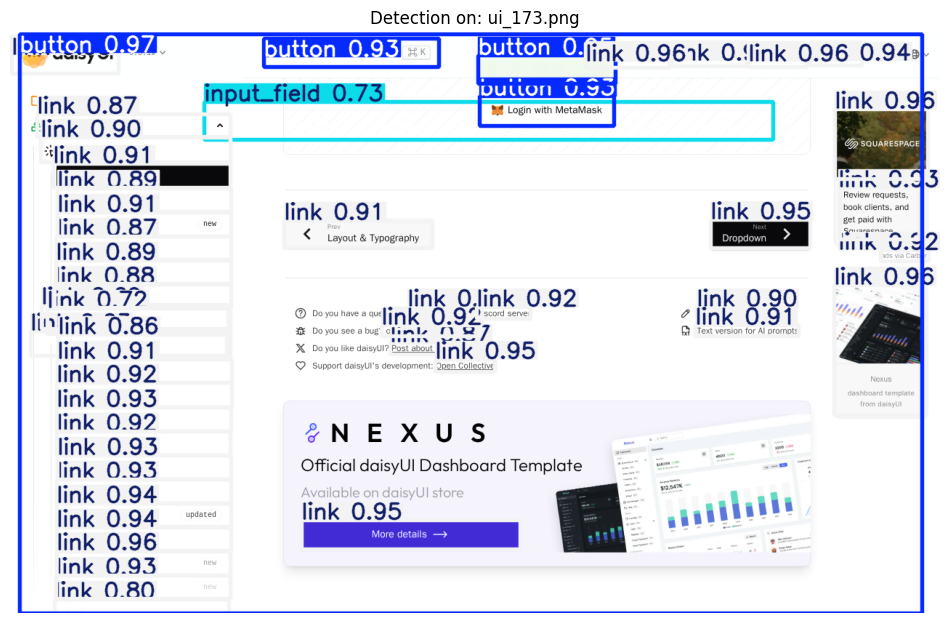


image 1/1 /content/yolo_dataset_pro/images/ui_330.png: 416x640 2 buttons, 1 input_field, 102 links, 8.8ms
Speed: 2.3ms preprocess, 8.8ms inference, 1.9ms postprocess per image at shape (1, 3, 416, 640)


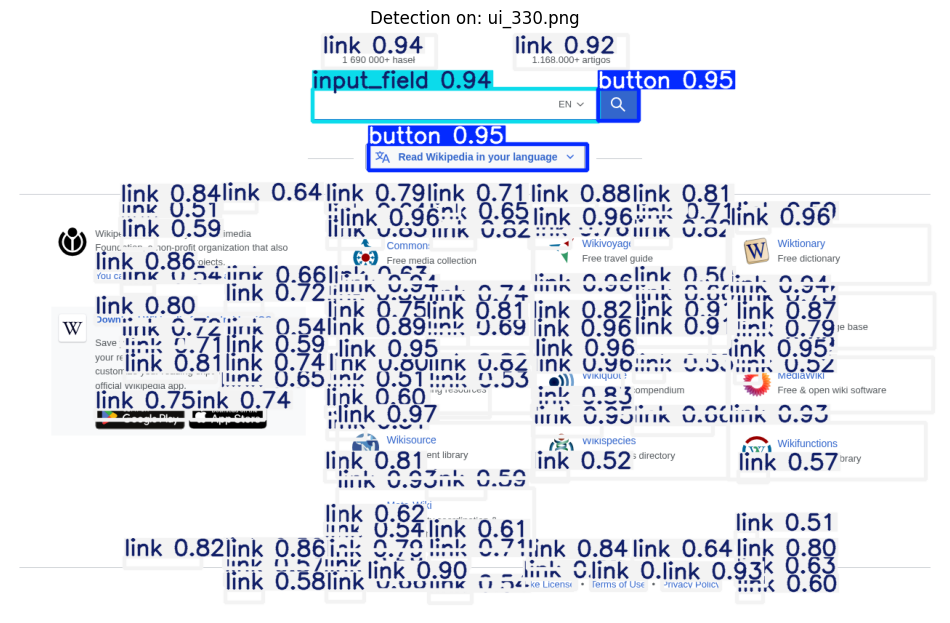


image 1/1 /content/yolo_dataset_pro/images/ui_358.png: 416x640 1 link, 8.3ms
Speed: 2.3ms preprocess, 8.3ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 640)


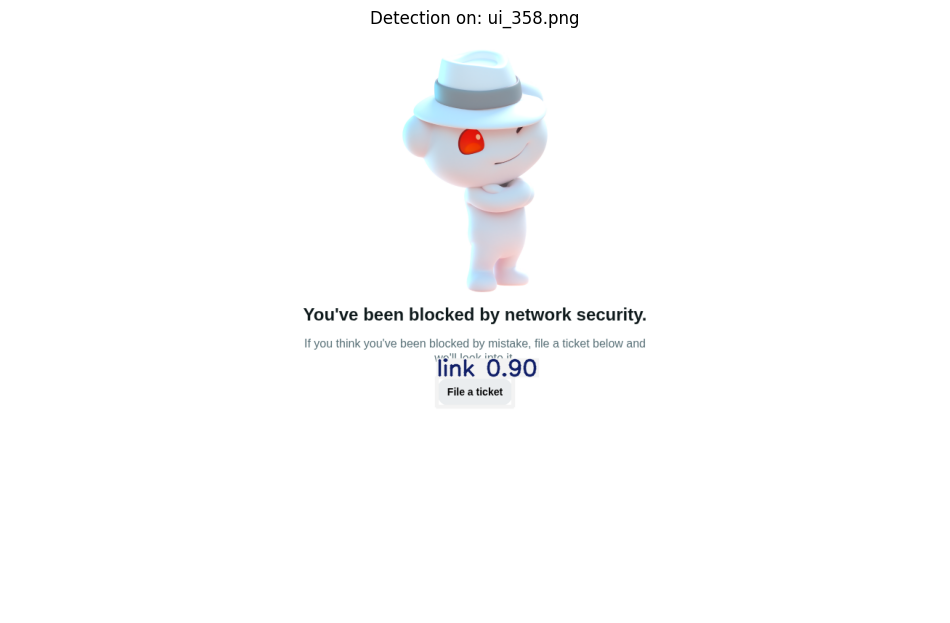

In [10]:
import glob
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# 1. Load your best model
model = YOLO('/content/runs/detect/vision_test_ai_final-2/weights/best.pt')

# 2. Run prediction on a few validation images
# We take 3 random images from the dataset
test_images = glob.glob(f"/content/{BASE_DIR}/images/*.png")[:3]

for img_path in test_images:
    results = model.predict(source=img_path, conf=0.5) # only show confident detections

    # Plotting
    res_plotted = results[0].plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Detection on: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

📊 Confusion Matrix:


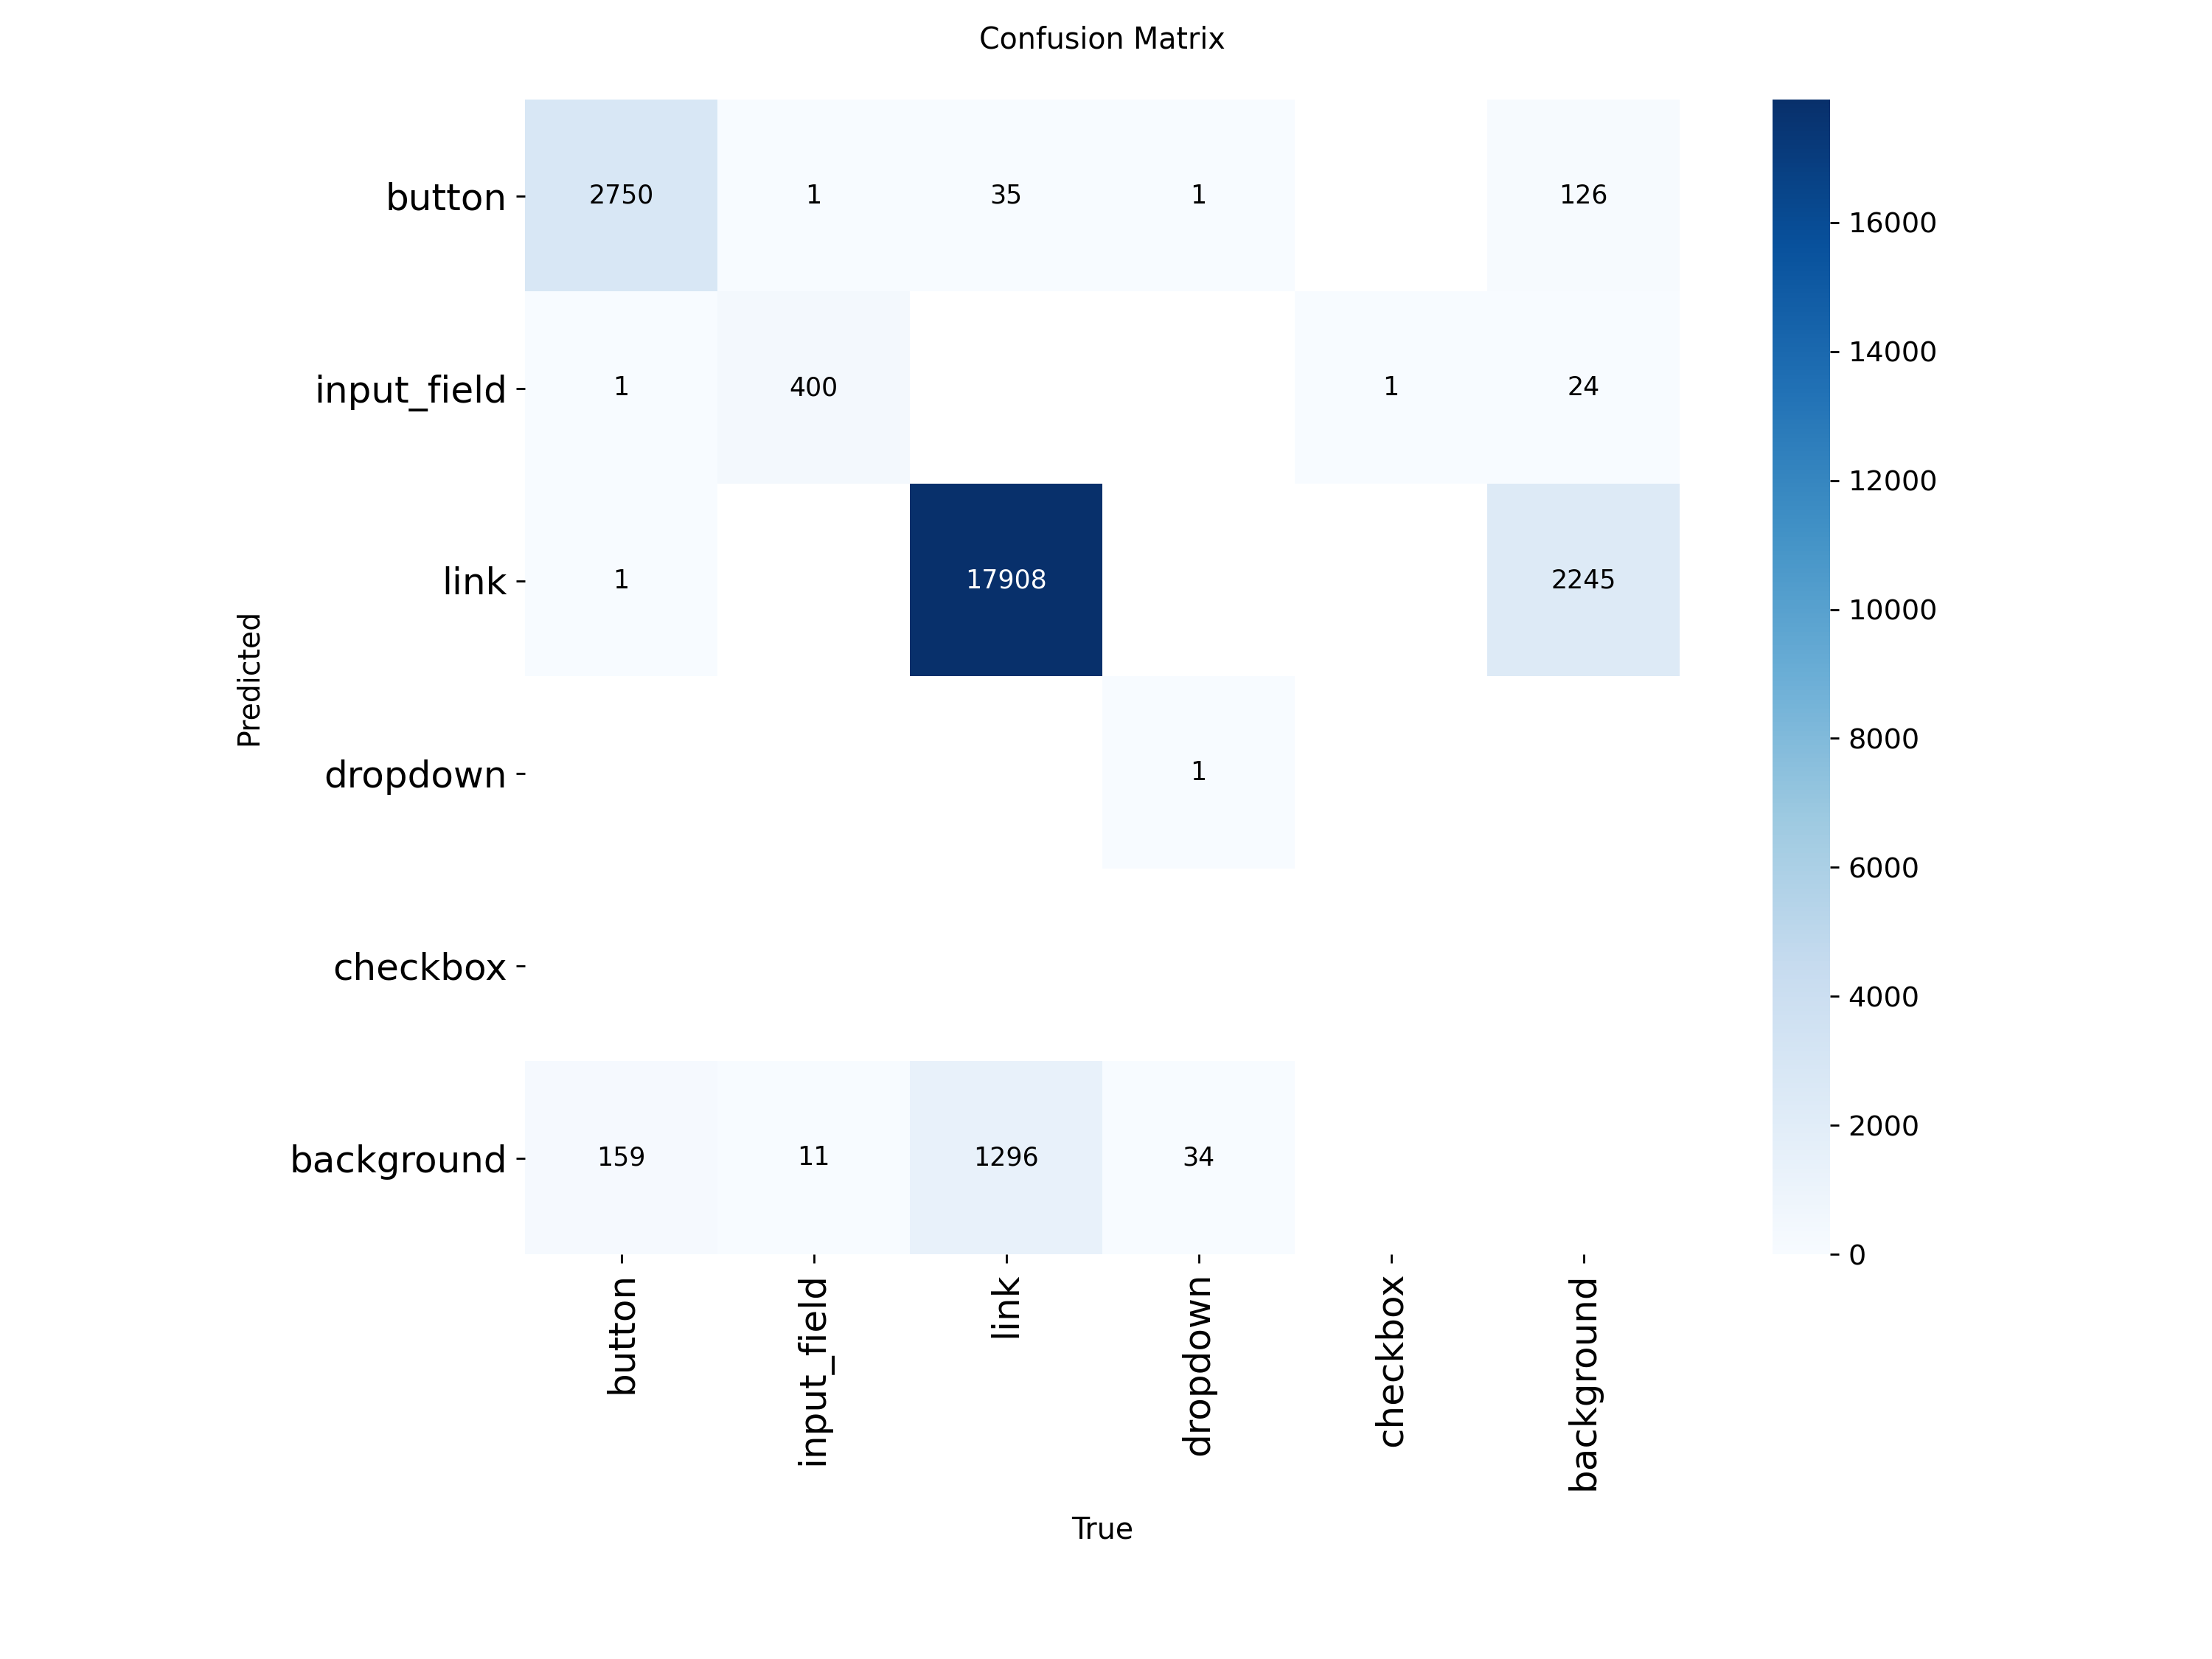

📈 Training Metrics:


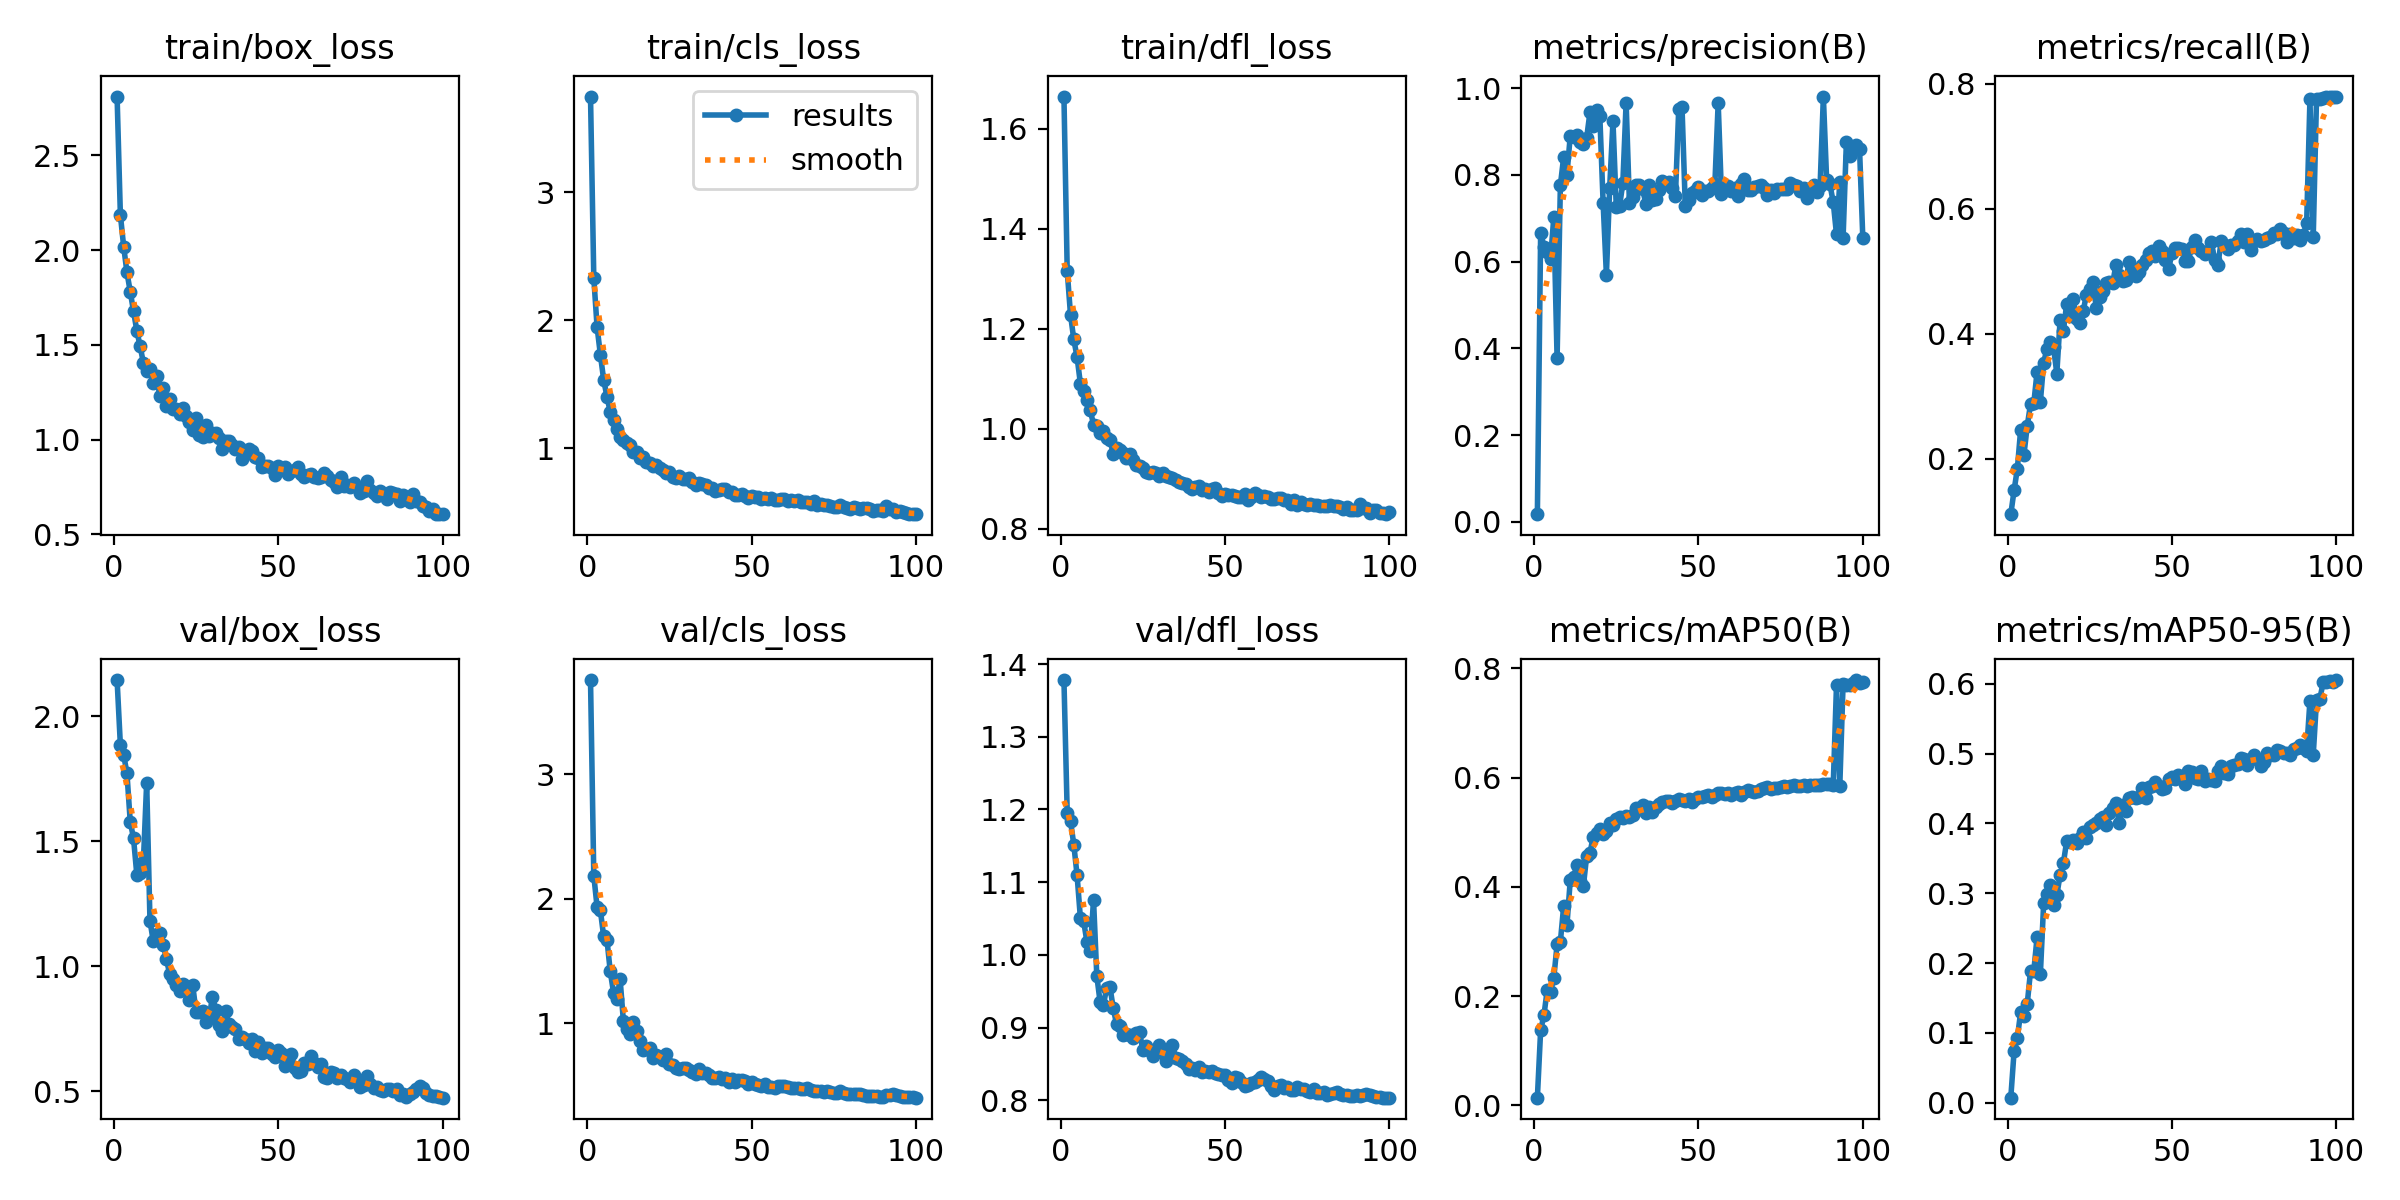

In [11]:
# This will display the confusion matrix and PR curves saved during training
from IPython.display import Image, display

# Display the Confusion Matrix
print("📊 Confusion Matrix:")
display(Image(filename='/content/runs/detect/vision_test_ai_final-2/confusion_matrix.png'))

# Display Results Graphs (Loss, mAP)
print("📈 Training Metrics:")
display(Image(filename='/content/runs/detect/vision_test_ai_final-2/results.png'))


image 1/1 /content/external_test.png: 416x640 3 buttons, 14 links, 9.5ms
Speed: 2.5ms preprocess, 9.5ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)


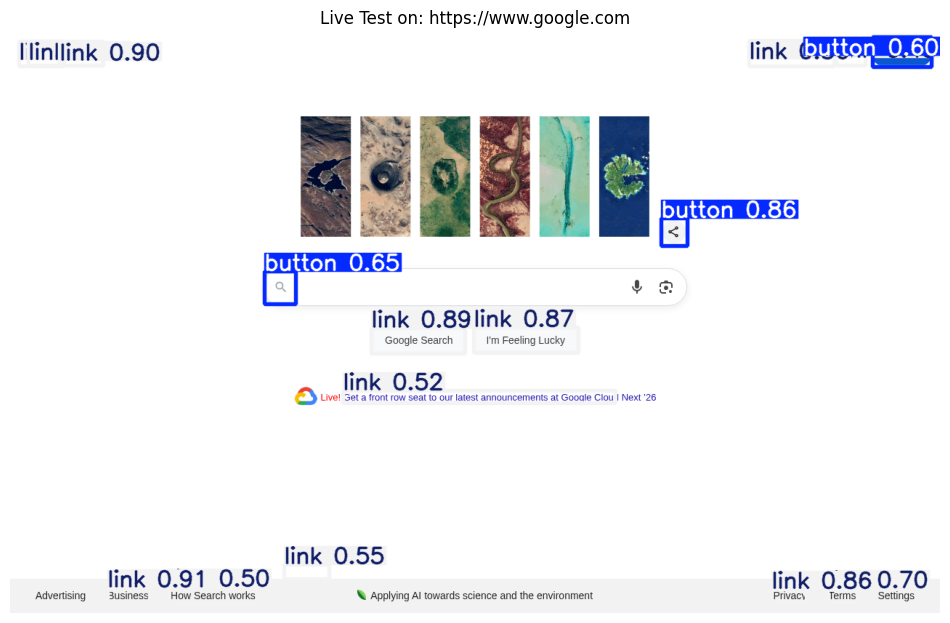

In [12]:
async def test_on_new_site(url):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page(viewport={'width': 1280, 'height': 800})
        await page.goto(url, wait_until="networkidle")

        test_path = "external_test.png"
        await page.screenshot(path=test_path)
        await browser.close()

        # Inference
        results = model.predict(source=test_path, conf=0.4)
        res_plotted = results[0].plot()

        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
        plt.title(f"Live Test on: {url}")
        plt.axis('off')
        plt.show()

# Run it on a fresh site
import nest_asyncio
nest_asyncio.apply()
asyncio.run(test_on_new_site("https://www.google.com"))